In [26]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/prevek18/ames-housing-dataset/AmesHousing.csv


# **Load the data**

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [28]:
df = pd.read_csv('/kaggle/input/datasets/prevek18/ames-housing-dataset/AmesHousing.csv')

# **Exploring the data**

In [29]:
df.head() #the first 5 rows

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [30]:
df.shape # to see how many rows, colunms we have

(2930, 82)

In [31]:
df.describe() 

,Order,PID,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,...,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice
count,2930.00000,2.930000e+03,2930.000000,2440.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2907.000000,...,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000
mean,1465.50000,7.144645e+08,57.387372,69.224590,10147.921843,6.094881,5.563140,1971.356314,1984.266553,101.896801,...,93.751877,47.533447,23.011604,2.592491,16.002048,2.243345,50.635154,6.216041,2007.790444,180796.060068
std,845.96247,1.887308e+08,42.638025,23.365335,7880.017759,1.411026,1.111537,30.245361,20.860286,179.112611,...,126.361562,67.483400,64.139059,25.141331,56.087370,35.597181,566.344288,2.714492,1.316613,79886.692357
min,1.00000,5.263011e+08,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,12789.000000
25%,733.25000,5.284770e+08,20.000000,58.000000,7440.250000,5.000000,5.000000,1954.000000,1965.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,2007.000000,129500.000000
50%,1465.50000,5.354536e+08,50.000000,68.000000,9436.500000,6.000000,5.000000,1973.000000,1993.000000,0.000000,...,0.000000,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,160000.000000
75%,2197.75000,9.071811e+08,70.000000,80.000000,11555.250000,7.000000,6.000000,2001.000000,2004.000000,164.000000,...,168.000000,70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,213500.000000
max,2930.00000,1.007100e+09,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,...,1424.000000,742.000000,1012.000000,508.000000,576.000000,800.000000,17000.000000,12.000000,2010.000000,755000.000000


# **Data types**

In [32]:
df.info()
 #MS SubClass colunm AND Mo Sold colunm are wrong datatype 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   object 
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   object 
 7   Alley            198 non-null    object 
 8   Lot Shape        2930 non-null   object 
 9   Land Contour     2930 non-null   object 
 10  Utilities        2930 non-null   object 
 11  Lot Config       2930 non-null   object 
 12  Land Slope       2930 non-null   object 
 13  Neighborhood     2930 non-null   object 
 14  Condition 1      2930 non-null   object 
 15  Condition 2      2930 non-null   object 
 16  Bldg Type        2930 non-null   object 
 17  House Style   

In [33]:
def Data_types(df):
    df["MS SubClass"]=df["MS SubClass"].astype('category')
    df["MS SubClass"].info()
# convert "MS SubClass" type 
    df["Mo Sold"]=df["Mo Sold"].astype('category')
    df["Mo Sold"].info()
# convert "Mo Sold" type 
    df["SalePrice"]=pd.to_numeric(df["SalePrice"],errors='coerce')
# convert "SalePrice" type
    return df

# **Missing values**

In [34]:
df.isna().sum().sort_values(ascending=False)

Pool QC           2917
Misc Feature      2824
Alley             2732
Fence             2358
Mas Vnr Type      1775
                  ... 
Mo Sold              0
Yr Sold              0
Sale Type            0
Sale Condition       0
SalePrice            0
Length: 82, dtype: int64

In [35]:
def custom_missing(df):
    custom = ["N/A", "NA", "not reported", "unknown", "?"]
    cols = df.select_dtypes(include=["category"]).columns
    for col in cols:
        df[col]=df[col].replace(custom, np.nan)
    return df

In [36]:
def missing_values1(df):
    df=df.drop(columns=["Pool QC","Misc Feature","Alley","Fence"])
# drop these coulnms because they have a lot of missing values
#(more than 90% is NULL )
    return df

In [37]:
df.isna().sum().sort_values(ascending=False)

Pool QC           2917
Misc Feature      2824
Alley             2732
Fence             2358
Mas Vnr Type      1775
                  ... 
Mo Sold              0
Yr Sold              0
Sale Type            0
Sale Condition       0
SalePrice            0
Length: 82, dtype: int64

In [38]:
#categorical columns have a lot of Null values
print(df["Mas Vnr Type"].head())
print(df["Fireplace Qu"].head())
print(df["Garage Finish"].head())

#numeric columns have a lot of Null values
print(df["Lot Frontage"].head())
print(df["Garage Yr Blt"].head())

0      Stone
1        NaN
2    BrkFace
3        NaN
4        NaN
Name: Mas Vnr Type, dtype: object
0     Gd
1    NaN
2    NaN
3     TA
4     TA
Name: Fireplace Qu, dtype: object
0    Fin
1    Unf
2    Unf
3    Fin
4    Fin
Name: Garage Finish, dtype: object
0    141.0
1     80.0
2     81.0
3     93.0
4     74.0
Name: Lot Frontage, dtype: float64
0    1960.0
1    1961.0
2    1958.0
3    1968.0
4    1997.0
Name: Garage Yr Blt, dtype: float64


In [39]:
def missing_values2(df):
#fill missing values with mode for categorical columns
#here we have to fill not drop because Null values are less
    category_cols = df.select_dtypes(include=["category"]).columns
    for col in category_cols:
        df[col]=df[col].fillna(df[col].mode(dropna=True)[0])

    #fill missing values with mean for numeric columns 
    #here we have to fill not drop because Null values are less
    numeric_cols = df.select_dtypes(include=["number"]).columns
    for col in numeric_cols:
        df[col]=df[col].fillna(df[col].mean())

    # i used here a median imputation for skewed distributions columns 
    df["Lot Frontage"]=df["Lot Frontage"].fillna(df["Lot Frontage"].median())
    df["Garage Yr Blt"]=df["Garage Yr Blt"].fillna(df["Garage Yr Blt"].median())
    return df

# **Handle duplicates**

In [40]:
def Handle_duplicates(df):
    print(df.duplicated().sum())
    df = df.drop_duplicates()
    return df

# **Spot outliers**

Text(0, 0.5, 'SalePrice')

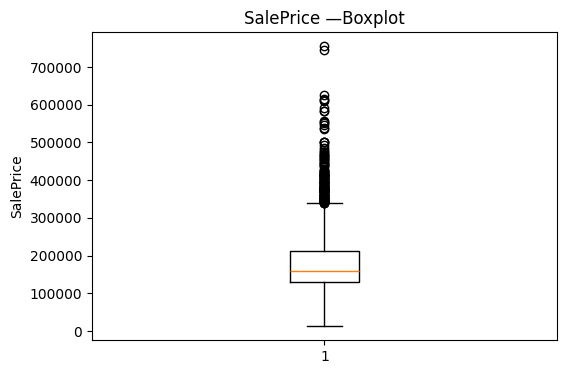

In [41]:
plt.figure(figsize=(6, 4))
plt.boxplot(df["SalePrice"], vert=True, showfliers=True)
plt.title("SalePrice —Boxplot"); plt.ylabel("SalePrice")


**there is a lot of outliers!!!!!!**

In [42]:
def iqr_bounds(s, k=1.5):
    """ IQR method on the target column"""
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 -q1
    return q1 -k * iqr, q3 + k * iqr

In [43]:
def capping(s: pd.Series) -> pd.Series:
    '''cap extreme values at the 99th percentile'''
    upper =s.quantile(0.99)
    return s.clip( upper=upper)

# **clean_data() function**

In [44]:
def clean_data(df):
    df=Data_types(df)

    df=custom_missing(df)
    df=missing_values1(df)
    df=missing_values2(df)
    
    df=Handle_duplicates(df)
    
    lower,upper=iqr_bounds(df["SalePrice"])#target column
    df["SalePrice"]=capping(df["SalePrice"])#target column
    
    return df

In [45]:
df=clean_data(df)

<class 'pandas.core.series.Series'>
RangeIndex: 2930 entries, 0 to 2929
Series name: MS SubClass
Non-Null Count  Dtype   
--------------  -----   
2930 non-null   category
dtypes: category(1)
memory usage: 3.7 KB
<class 'pandas.core.series.Series'>
RangeIndex: 2930 entries, 0 to 2929
Series name: Mo Sold
Non-Null Count  Dtype   
--------------  -----   
2930 non-null   category
dtypes: category(1)
memory usage: 3.4 KB
0


In [46]:
df.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Lot Shape,Land Contour,Utilities,...,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,IR1,Lvl,AllPub,...,0,0,0,0,0,5,2010,WD,Normal,215000.0
1,2,526350040,20,RH,80.0,11622,Pave,Reg,Lvl,AllPub,...,0,0,120,0,0,6,2010,WD,Normal,105000.0
2,3,526351010,20,RL,81.0,14267,Pave,IR1,Lvl,AllPub,...,0,0,0,0,12500,6,2010,WD,Normal,172000.0
3,4,526353030,20,RL,93.0,11160,Pave,Reg,Lvl,AllPub,...,0,0,0,0,0,4,2010,WD,Normal,244000.0
4,5,527105010,60,RL,74.0,13830,Pave,IR1,Lvl,AllPub,...,0,0,0,0,0,3,2010,WD,Normal,189900.0


# **checks**

In [47]:
def checking(df):
    assert df["SalePrice"].min() >= 0, "Negative SalePrice found"
    assert df.duplicated().sum() == 0, "There are duplicate rows"
    assert df["SalePrice"].notna().all().all(), "SalePrise still has NaN"
checking(df)

In [48]:
checking(df)

In [49]:
df.to_csv("cleaned_data.csv", index=False)

# Bonus 💥



I used the dataset "AmesHousing.csv". The dataset contains ((2930)) records and ((82)) columns. After analyzing the data, I found that the average value is (179,956.70). The highest value is (456,666.37) and the lowest value is (12,789).

My classmate "Deema Alsaweed" used the dataset "Melbourne Housing" .When we compared the results, we noticed that the values in the two datasets are different. The difference in results may be because each dataset represents a different topic and contains different records.

In conclusion, using different datasets can lead to different results and insights.